In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import SymLogNorm

# Data loading

In [20]:
data_full = pd.read_csv("../data/pantheon_sn_data.csv")
print(data_full.columns)
print(len(data_full))
data_full.head()

Index(['name', 'z', 'z_err', 'mu', 'mu_err'], dtype='str')
1701


,name,z,z_err,mu,mu_err
0,2011fe,0.00122,0.00084,28.9987,1.516450
1,2011fe,0.00122,0.00084,29.0559,1.517470
2,2012cg,0.00256,0.00084,30.7233,0.782372
3,2012cg,0.00256,0.00084,30.7449,0.799068
4,1994DRichmond,0.00299,0.00084,30.7757,0.881212


In [ ]:
cov_full_f = np.load("../data/pantheon_cov.npz")
triu = cov_full_f["triu"]
n = cov_full_f["n"]
cov_full = np.zeros((n, n))
cov_full[np.triu_indices(n)] = triu
cov_full = cov_full + cov_full.T - np.diag(np.diag(cov_full))

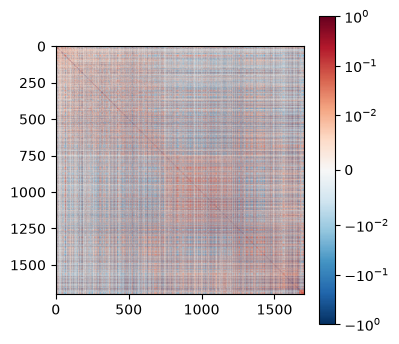

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
rho = cov_full / np.sqrt(np.outer(np.diag(cov_full), np.diag(cov_full)))
mesh = ax.imshow(rho, cmap="RdBu_r", norm=SymLogNorm(vmin=-1, vmax=1, linthresh=0.01))
fig.colorbar(mesh)

In [ ]:
posterior_mask = (data_full["z"] >= 0.01).to_numpy()
data = data_full.loc[posterior_mask]
cov = cov_full[np.ix_(posterior_mask, posterior_mask)]

# Simulator

In [49]:
def pen_approx_eta(a, Omega_m):
    s3 = (1 - Omega_m) / Omega_m
    s = s3 ** (1 / 3)
    return (
        2
        * np.sqrt(s3 + 1)
        * (1 / a**4 + 0.1540 * s / a**3 + 0.4340 * s**2 / a**2 + 0.19097 * s**3 / a + 0.066941 * s**4) ** (-1 / 8)
    )


c = 3e5  # speed of light in km/s


def luminocity_distance(z, h, Omega_m):
    H0 = 100 * h
    return c * (1 + z) / H0 * (pen_approx_eta(1, Omega_m) - pen_approx_eta(1 / (1 + z), Omega_m))


def mu_th(z, h, Omega_m):
    return 5 * np.log10(luminocity_distance(z, h, Omega_m)) + 25

Text(0, 0.5, 'Theoretical $\\mu$')

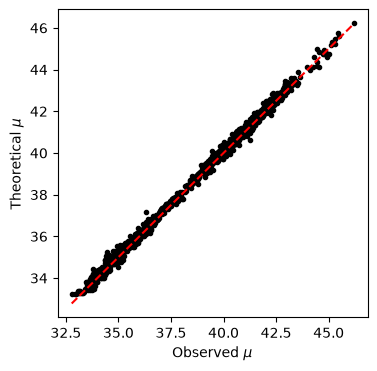

In [53]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(data["mu"], mu_th(data["z"], h=0.7, Omega_m=0.3), color="k", marker=".")

mu_min = data["mu"].min()
mu_max = data["mu"].max()
ax.plot([mu_min, mu_max], [mu_min, mu_max], color="r", linestyle="--")
ax.set_xlabel("Observed $\\mu$")
ax.set_ylabel("Theoretical $\\mu$")

In [301]:
L_T = np.linalg.cholesky(cov).T
redshift = data["z"].to_numpy()


def simulator(h: np.ndarray, Omega_m: np.ndarray):
    theta_size = h.size
    eps = np.random.normal(size=(theta_size, len(redshift)))
    noise = eps @ L_T
    return mu_th(redshift, h[:, None], Omega_m[:, None]) + noise


def simulator_scalar(h: float, Omega_m: float):
    return simulator(np.array([h]), np.array([Omega_m]))

In [216]:
simulator(
    h=np.array([0.7, 0.71, 0.72]),
    Omega_m=np.array([0.3, 0.31, 0.32]),
).shape

(3, 1590)

In [ ]:
redshifts_sorted = np.sort(redshift)

n_bins = 15
redshift_binning = np.quantile(redshifts_sorted, np.linspace(0, 1, n_bins + 1))
redshift_binning[-1] += 10

bin_indices = np.digitize(redshift, redshift_binning) - 1

for bin in range(n_bins):
    print(bin, "->", len(redshift[bin_indices == bin]))

0 -> 106
1 -> 106
2 -> 106
3 -> 106
4 -> 106
5 -> 106
6 -> 106
7 -> 106
8 -> 106
9 -> 106
10 -> 106
11 -> 106
12 -> 106
13 -> 106
14 -> 106


In [218]:
binning_weights = 1 / cov.diagonal()
print(binning_weights)

[15.28189934 14.42876341 16.87219804 ... 24.05365155 14.8305833
 22.22713613]


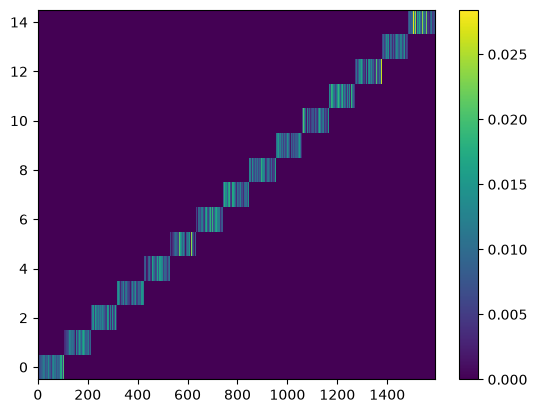

In [ ]:
binning_projector = np.zeros((n_bins, len(redshift)))

for bin in range(n_bins):
    binning_projector[bin, bin_indices == bin] = binning_weights[bin_indices == bin]

binning_projector /= binning_projector.sum(axis=1, keepdims=True)

plt.pcolormesh(binning_projector, shading="nearest")
plt.colorbar()

In [220]:
def summary_binned(
    mu: np.ndarray,  # (batch, SNs)
):
    return np.tensordot(mu, binning_projector, axes=([1], [1]))

In [231]:
s_data = summary_binned(data["mu"].to_numpy()[None, :]).squeeze()
print(s_data)

[33.82991498 34.59755637 35.06739501 35.5690987  36.18304617 37.2966252
 38.93030998 39.6634354  40.1086036  40.49840342 40.9335898  41.2478641
 41.78929698 42.38858899 43.37647983]


In [223]:
summary_binned(simulator_scalar(0.7, 0.3))

array([[33.93970904, 34.73091669, 35.27588147, 35.66398172, 36.30331426,
        37.39967519, 39.08526895, 39.81385655, 40.2434145 , 40.64269174,
        41.03047195, 41.32393981, 41.87023158, 42.46085705, 43.45219467]])

# ABC from scratch

In [233]:
def sample_prior(batch_size: int):
    # returns batches of (h, Omega_m) sampled from prior
    return np.random.uniform(size=(batch_size, 2), low=[[0.3, 0.1]], high=[[1.0, 1.0]])


sample_prior(5).shape

(5, 2)

In [ ]:
n_sim = 50_000
theta = sample_prior(n_sim)
s_sample = summary_binned(simulator(theta[:, 0], theta[:, 1]))
s_sample.shape

(50000, 15)

In [278]:
rho_whitened = np.sqrt(np.sum(((s_sample - s_data) / np.std(s_sample, axis=0)) ** 2, axis=1)) / np.sqrt(
    s_sample.shape[1]
)

In [279]:
s_cov = binning_projector @ cov @ binning_projector.T
s_L = np.linalg.cholesky(s_cov)
perdim_rho_noise = np.linalg.inv(s_L) @ (s_sample - s_data).T
rho_noise = np.sqrt(np.sum(perdim_rho_noise**2, axis=0))

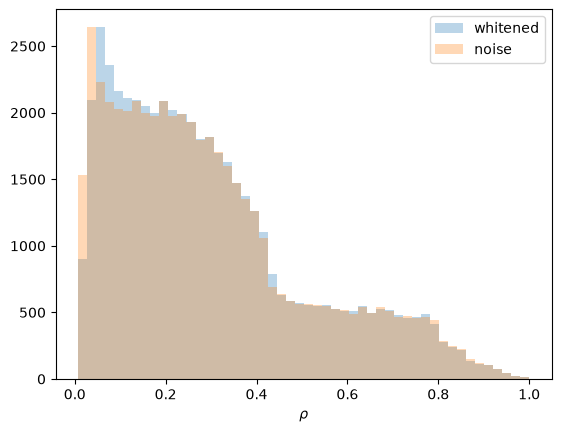

In [280]:
fig, ax = plt.subplots()
ax.hist(rho_whitened / rho_whitened.max(), bins=50, alpha=0.3, label="whitened")
ax.hist(rho_noise / rho_noise.max(), bins=50, alpha=0.3, label="noise")
ax.set_xlabel("$\\rho$")
ax.legend()

In [ ]:
rho = rho_whitened  # no practical difference
eps = 0.01
posterior_mask = rho < np.quantile(rho, eps)
s_sample_posterior = s_sample[posterior_mask, :]
print(s_sample_posterior.shape)

(500, 15)


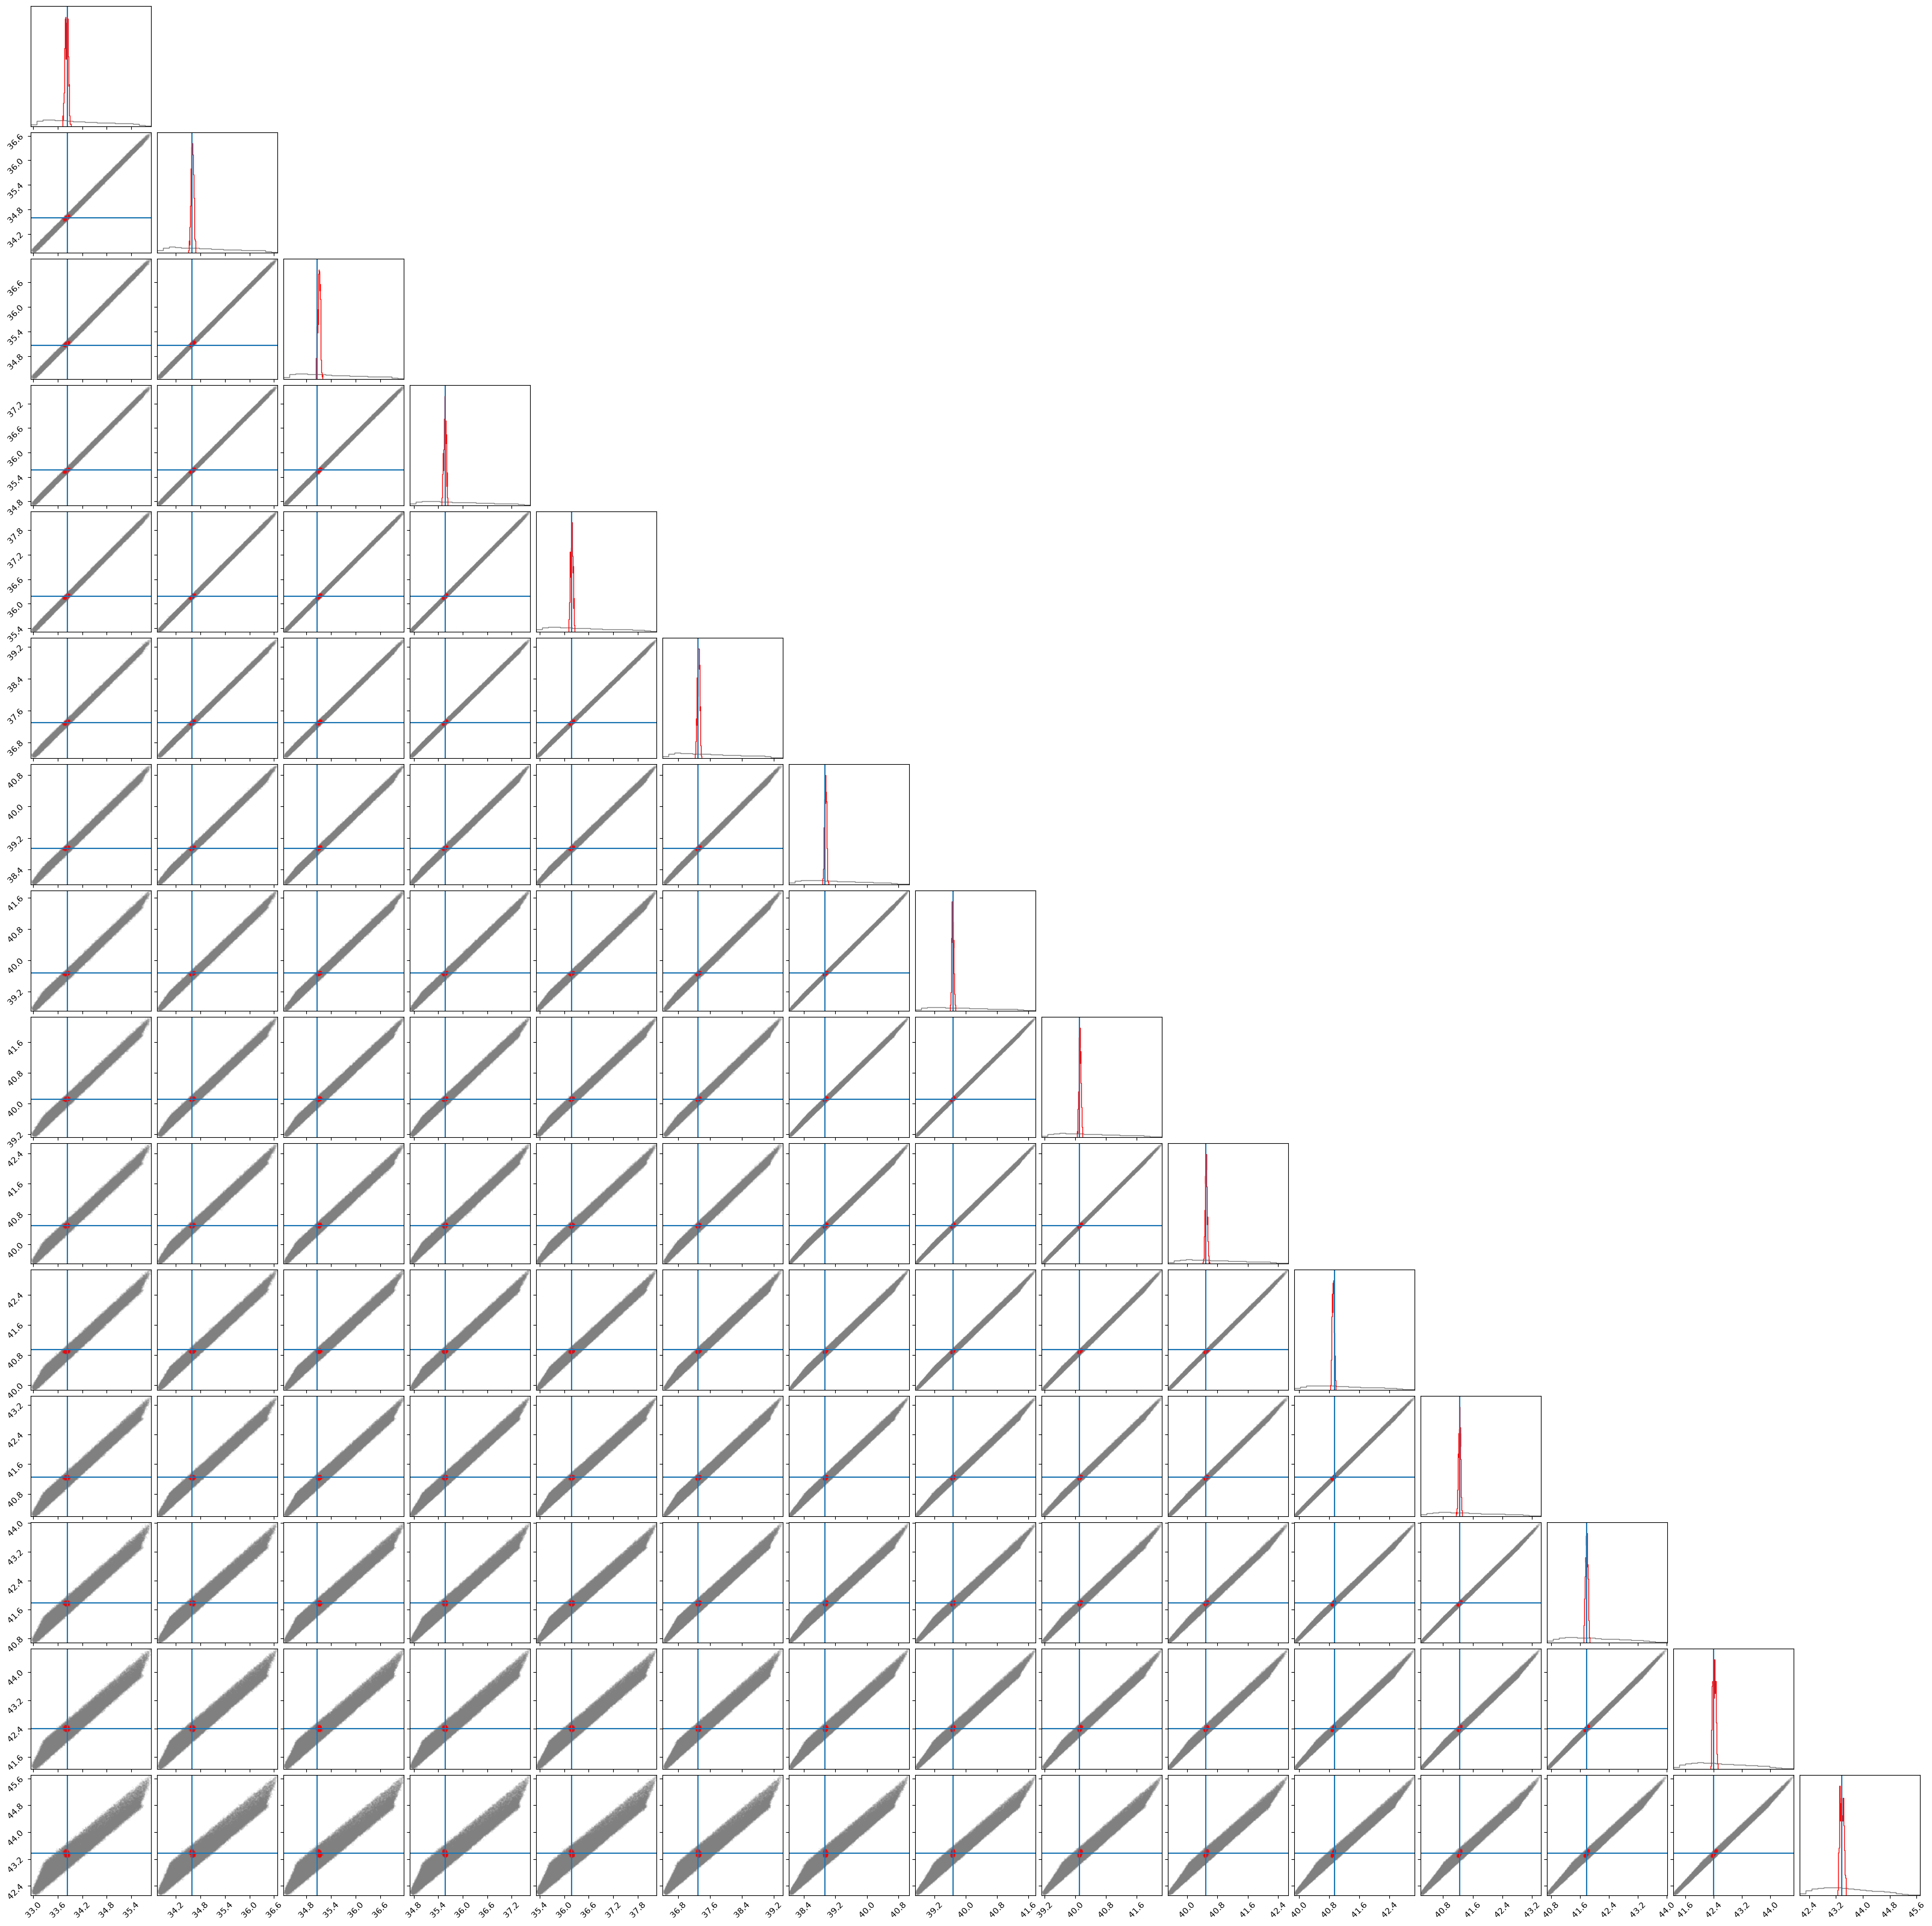

In [282]:
import corner


def corner_kw(color):
    return dict(
        plot_contours=False,
        plot_density=False,
        hist_kwargs={"density": True, "color": color},
        color=color,
    )


fig = corner.corner(s_sample, **corner_kw("gray"))
corner.corner(s_sample_posterior, fig=fig, **corner_kw("red"))
corner.overplot_lines(fig, xs=s_data)

(10000, 15)
(5000, 15)
(2500, 15)
(500, 15)
(250, 15)


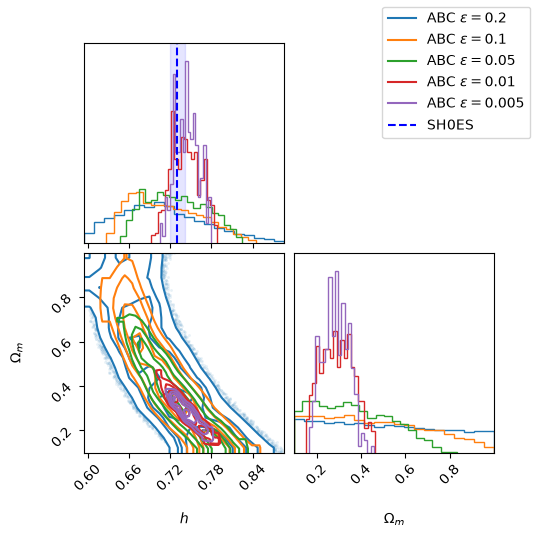

In [297]:
fig = None

rho = rho_whitened  # no practical difference
cmap = plt.get_cmap("tab10")
eps_values = [0.2, 0.1, 0.05, 0.01, 0.005]
for i, eps in enumerate(eps_values):
    posterior_mask = rho < np.quantile(rho, eps)
    s_sample_posterior = s_sample[posterior_mask, :]
    print(s_sample_posterior.shape)

    color = cmap(i)
    fig = corner.corner(
        theta[posterior_mask, :],
        fig=fig,
        hist_kwargs={"density": True, "color": color},
        # show_titles=True,
        labels=[r"$h$", r"$\Omega_m$"],
        color=color,
        plot_density=False,
        smooth=1.0,
    )

assert fig is not None
# reference SH0ES result
h_ref = 0.7304
h_ref_err = 0.0104
fig.axes[0].axvline(h_ref, color="blue", linestyle="--")
fig.axes[0].axvspan(
    h_ref - h_ref_err,
    h_ref + h_ref_err,
    color="blue",
    alpha=0.1,
)

fig.legend(
    handles=[
        *[
            plt.Line2D([], [], color=cmap(i), linestyle="-", label=f"ABC $\\epsilon={eps}$")
            for i, eps in enumerate(eps_values)
        ],
        plt.Line2D([], [], color="blue", linestyle="--", label="SH0ES"),
    ],
)

## MOPED estimators

In [428]:
h_star = 0.7
Omega_m_star = 0.3

eps = 0.0001
dmu_dh = (mu_th(redshift, h_star + eps, Omega_m_star) - mu_th(redshift, h_star - eps, Omega_m_star)) / (2 * eps)
dmu_dOmega_m = (mu_th(redshift, h_star, Omega_m_star + eps) - mu_th(redshift, h_star, Omega_m_star - eps)) / (2 * eps)

_num_h = np.linalg.solve(cov, dmu_dh)
b_h = _num_h / np.sqrt(dmu_dh @ _num_h)

_num_Omega_m = np.linalg.solve(cov, dmu_dOmega_m)
b_Omega_m = (_num_Omega_m - dmu_dOmega_m @ b_h * b_h) / np.sqrt(dmu_dOmega_m @ _num_Omega_m - (dmu_dOmega_m @ b_h) ** 2)

B = np.stack([b_h, b_Omega_m])
B.shape

(2, 1590)

In [429]:
B @ cov @ B.T

array([[1.00000000e+00, 3.33066907e-16],
       [5.55111512e-16, 1.00000000e+00]])

In [430]:
def summary_moped(
    mu: np.ndarray,  # (batch, SNs)
):
    return np.tensordot(mu, B, axes=([1], [1]))

In [431]:
s_m_data = summary_moped(data["mu"].to_numpy()[None, :]).squeeze()

In [432]:
s_m_data

array([-10260.75597866,   -448.38171148])

In [433]:
n_sim = 50_000
theta = sample_prior(n_sim)
s_m_sample = summary_moped(simulator(theta[:, 0], theta[:, 1]))
s_m_sample.shape

(50000, 2)

In [434]:
rho = np.sqrt(np.sum((s_m_sample - s_m_data) ** 2, axis=1))
eps = 0.01
posterior_mask = rho < np.quantile(rho, eps)
s_m_sample_posterior = s_m_sample[posterior_mask, :]
print(s_m_sample_posterior.shape)

(500, 2)


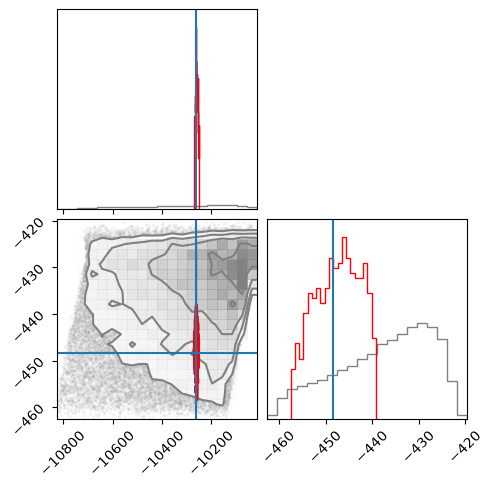

In [435]:
import corner


def corner_kw(color):
    return dict(  # noqa: C408
        # plot_contours=False,
        # plot_density=False,
        hist_kwargs={"density": True, "color": color},
        color=color,
    )


fig = corner.corner(s_m_sample, **corner_kw("gray"))
corner.corner(s_m_sample_posterior, fig=fig, **corner_kw("red"))
corner.overplot_lines(fig, xs=s_m_data)

(10000, 2)
(5000, 2)
(2500, 2)
(500, 2)
(250, 2)


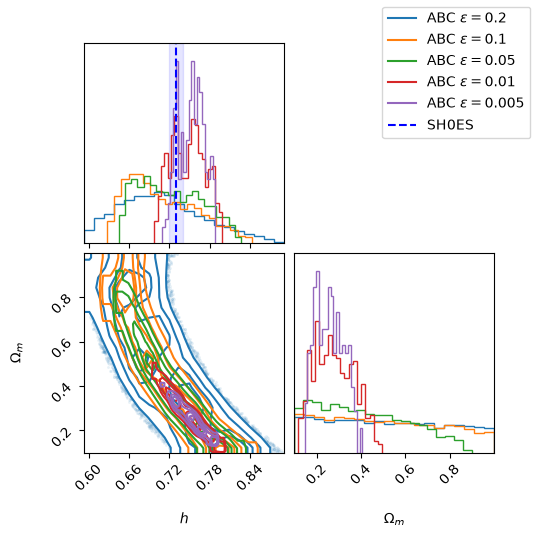

In [436]:
fig = None

cmap = plt.get_cmap("tab10")
eps_values = [0.2, 0.1, 0.05, 0.01, 0.005]
for i, eps in enumerate(eps_values):
    posterior_mask = rho < np.quantile(rho, eps)
    s_m_sample_posterior = s_m_sample[posterior_mask, :]
    print(s_m_sample_posterior.shape)

    color = cmap(i)
    fig = corner.corner(
        theta[posterior_mask, :],
        fig=fig,
        hist_kwargs={"density": True, "color": color},
        # show_titles=True,
        labels=[r"$h$", r"$\Omega_m$"],
        color=color,
        plot_density=False,
        smooth=1.0,
    )

assert fig is not None
fig.axes[0].axvline(h_ref, color="blue", linestyle="--")
fig.axes[0].axvspan(
    h_ref - h_ref_err,
    h_ref + h_ref_err,
    color="blue",
    alpha=0.1,
)

fig.legend(
    handles=[
        *[
            plt.Line2D([], [], color=cmap(i), linestyle="-", label=f"ABC $\\epsilon={eps}$")
            for i, eps in enumerate(eps_values)
        ],
        plt.Line2D([], [], color="blue", linestyle="--", label="SH0ES"),
    ],
)

## Comparison

In [437]:
from collections.abc import Callable


def sample_abc(summary: Callable[[np.ndarray], np.ndarray], n_sim: int, eta: float):
    theta = sample_prior(n_sim)

    # batch theta in 10k along the first dimension
    batch_size = 10_000
    n_batches = n_sim // batch_size
    prior_sample = None
    for theta_batch in np.array_split(theta, n_batches):
        prior_sample_batch = summary(simulator(theta_batch[:, 0], theta_batch[:, 1]))
        if prior_sample is not None:
            prior_sample = np.vstack([prior_sample, prior_sample_batch])
        else:
            prior_sample = prior_sample_batch

    # prior_sample = summary(simulator(theta[:, 0], theta[:, 1]))
    s_data = summary(data["mu"].to_numpy()[None, :])

    # rho = np.sqrt(np.sum(((prior_sample - s_data) / np.std(prior_sample, axis=0)) ** 2, axis=1)) / np.sqrt(
    #     prior_sample.shape[1]
    # )
    rho = np.sqrt(np.sum((prior_sample - s_data) ** 2, axis=1))
    posterior_mask = rho < np.quantile(rho, eta)
    posterior_sample = prior_sample[posterior_mask, :]
    return theta[posterior_mask, :], posterior_sample

In [441]:
n_sim = 500_000
eta = 0.005
binned = sample_abc(summary=summary_binned, n_sim=n_sim, eta=eta)
moped = sample_abc(summary=summary_moped, n_sim=n_sim, eta=eta)

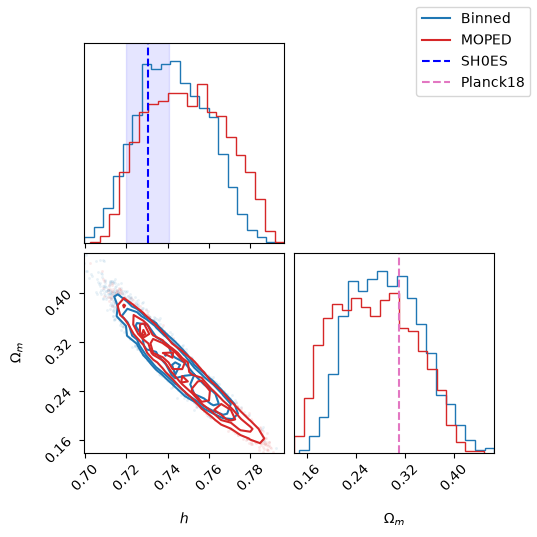

In [442]:
import corner


def corner_kw(color):
    return dict(  # noqa: C408
        # plot_contours=False,
        labels=["$h$", "$\\Omega_m$"],
        plot_density=False,
        hist_kwargs={"density": True, "color": color},
        color=color,
        smooth=0.1,
    )


fig = corner.corner(binned[0], **corner_kw("tab:blue"))
fig = corner.corner(moped[0], fig=fig, **corner_kw("tab:red"))

fig.axes[0].axvline(h_ref, color="blue", linestyle="--")
fig.axes[0].axvspan(
    h_ref - h_ref_err,
    h_ref + h_ref_err,
    color="blue",
    alpha=0.1,
)

Omega_m_ref = 0.30966
fig.axes[-1].axvline(Omega_m_ref, color="tab:pink", linestyle="--")

# corner.overplot_lines(fig, xs=s_m_data)
fig.legend(
    handles=[
        plt.Line2D([], [], color="tab:blue", linestyle="-", label="Binned"),
        plt.Line2D([], [], color="tab:red", linestyle="-", label="MOPED"),
        plt.Line2D([], [], color="blue", linestyle="--", label="SH0ES"),
        plt.Line2D([], [], color="tab:pink", linestyle="--", label="Planck18"),
    ],
)

# Part B: Neural Posterior Estimator

In [443]:
import torch
from sbi.inference import SNPE  # or SNLE, or SNRE
from sbi.utils import BoxUniform

/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_8334/2471822476.py:3: FutureWarning: `sbi.inference.SNPE` is deprecated since sbi v0.27.0 and will be removed in v0.28.0. Use `sbi.inference.NPE_C` instead.
  from sbi.inference import SNPE  # or SNLE, or SNRE


In [464]:
prior = BoxUniform(low=torch.tensor([0.3, 0.1]), high=torch.tensor([1.0, 1.0]))

theta_samples = sample_prior(batch_size=10_000)
theta = torch.as_tensor(theta_samples, dtype=torch.float32)  # (N, 2)

In [465]:
x_samples = summary_binned(simulator(theta_samples[:, 0], theta_samples[:, 1]))
x = torch.as_tensor(x_samples, dtype=torch.float32)  # (N, K)

In [466]:
inference = SNPE(prior=prior)  # or SNLE(prior=prior) / SNRE(prior=prior)
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 225 epochs.

In [473]:
x_obs = torch.as_tensor(summary_binned(data["mu"].to_numpy()[None, :]), dtype=torch.float32)  # (K,)
samples = posterior.sample((10000,), x=x_obs)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [474]:
samples.numpy()

array([[0.75263965, 0.2488935 ],
       [0.7583233 , 0.22523698],
       [0.7464261 , 0.26417044],
       ...,
       [0.7442327 , 0.2765461 ],
       [0.7514997 , 0.25556847],
       [0.73656607, 0.30575678]], shape=(10000, 2), dtype=float32)

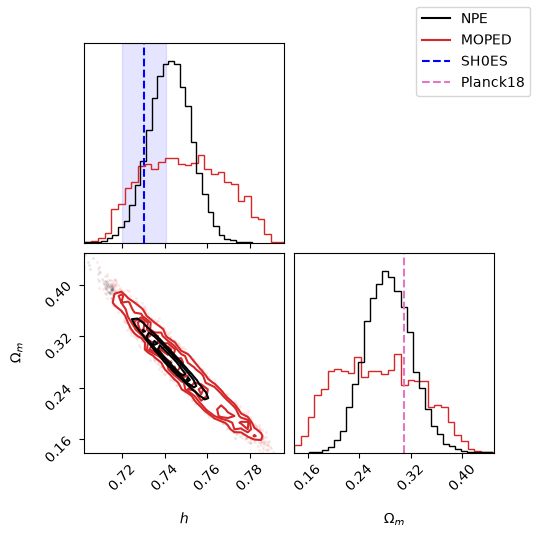

In [475]:
def corner_kw(color):
    return dict(  # noqa: C408
        # plot_contours=False,
        labels=["$h$", "$\\Omega_m$"],
        plot_density=False,
        hist_kwargs={"density": True, "color": color},
        color=color,
        smooth=0.1,
        bins=30,
    )


fig = corner.corner(moped[0], **corner_kw("tab:red"))
fig = corner.corner(samples.numpy(), **corner_kw("black"), fig=fig)

fig.axes[0].axvline(h_ref, color="blue", linestyle="--")
fig.axes[0].axvspan(
    h_ref - h_ref_err,
    h_ref + h_ref_err,
    color="blue",
    alpha=0.1,
)

Omega_m_ref = 0.30966
fig.axes[-1].axvline(Omega_m_ref, color="tab:pink", linestyle="--")

# corner.overplot_lines(fig, xs=s_m_data)
fig.legend(
    handles=[
        plt.Line2D([], [], color="black", linestyle="-", label="NPE"),
        plt.Line2D([], [], color="tab:red", linestyle="-", label="MOPED"),
        plt.Line2D([], [], color="blue", linestyle="--", label="SH0ES"),
        plt.Line2D([], [], color="tab:pink", linestyle="--", label="Planck18"),
    ],
)